**BBM473 Database Laboratory (Spring 2025)**


Exercise 5: Relational Algebra & Logical Equivalence and Optimization of Relational Algebra Expressions
=============================

Part 1: Relational Algebra & Logical Equivalence (100 pts.)
=============================

First, execute the following codes below.

**Note:** You may need to install `markdown`:

    $ pip install markdown

In [1]:
%load_ext sql
%sql sqlite://
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

%load_ext autoreload
%autoreload 2

# To help render markdown
from IPython.core.display import display, HTML
from markdown import markdown
def render_markdown_raw(m): return display(HTML(markdown(m))) # must be last element of cell.
def render_markdown(m): return render_markdown_raw(m.toMD())

# import the relational algbera operators
from relation_algebra import Select, Project, Union, NJoin, CrossProduct, BaseRelation
from relation_algebra import get_result, compare_results

from display_tools import side_by_side

import random

/var/folders/ph/d40bjj313kq3bmcc6_r6yxqw0000gn/T/ipykernel_2896/3653078174.py:9: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [2]:
%%sql
drop table if exists R; create table R(A int, B int);
drop table if exists S; create table S(B int, C int);
drop table if exists T; create table T(C int, D int);
drop table if exists U; create table U(D int, E int);

 * sqlite://
Done.
Done.
Done.
Done.
Done.
Done.
Done.
Done.


[]

In [3]:
for x in range(0,10,2):
    for y in range(0,10,3):
        %sql INSERT INTO R VALUES (:x, :y);
for x in range(0,20,4):
    for y in range(0,10,2):
        %sql INSERT INTO S VALUES (:x, :y);
for x in range(0,5,1):
    for y in range(0,10,2):
        %sql INSERT INTO T VALUES (:x, :y);
for x in range(0,10,2):
    for y in range(0,5,1):
        %sql INSERT INTO U VALUES (:x, :y);

 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite:

### Tutorial: Relational Algebra Python Toolkit

We'll use a python toolkit we made to play around with RA.  We'll get started with a quick tutorial, but the syntax should also be pretty intuitive (feel free to look at the source code too!)

#### BaseRelation class

Recall that in our RA operations we'll deal with sets; to get started, we need to take SQL output and turn it into a `BaseRelation` object, which we can optionally name:

In [4]:
r = %sql SELECT * FROM R;
R = BaseRelation(r, name="R")

s = %sql SELECT * FROM S;
S = BaseRelation(s, name="S")

t = %sql SELECT * FROM T;
T = BaseRelation(t, name="T")

u = %sql SELECT * FROM U;
U = BaseRelation(u, name="U")

 * sqlite://
Done.
 * sqlite://
Done.
 * sqlite://
Done.
 * sqlite://
Done.


For **all operators in our toolkit**, we can use `get_result` to see the set we have:

In [5]:
print(get_result(R))

[(0, 0), (0, 3), (0, 6), (0, 9), (2, 0), (2, 3), (2, 6), (2, 9), (4, 0), (4, 3), (4, 6), (4, 9), (6, 0), (6, 3), (6, 6), (6, 9), (8, 0), (8, 3), (8, 6), (8, 9)]


And (again **for all operators in our toolkit**) we can use `render_markdown(R)`

**_NOTE: This function requires that you have installed the `markdown` python library.  It's just for this function / pretty printing, so if you weren't able to install this library, don't worry!_**

**NOTE2: Even if you have installed the `markdown` library, the output of the function may be shown as raw (not rendered) markdown formula depending on your environment. In this case, you can paste the formula to a new markdown cell to display the nicely rendered output.**

In [6]:
render_markdown(R)
render_markdown(S)
render_markdown(T)

#### Selection, Projection, NJoin classes

In [7]:
s = Select("A", 2, R)
render_markdown(s)
print(get_result(s))

[(2, 0), (2, 3), (2, 6), (2, 9)]


$\sigma_{A=2}$(R(A,B))



In [8]:
p = Project(["A"], R)
render_markdown(p)
print (get_result(p))

[(6,), (2,), (8,), (4,), (0,)]


$\Pi_{A}$(R(A,B))



In [9]:
j = NJoin(R, S)
render_markdown(j)
print (get_result(j))

[(0, 0, 0), (0, 0, 2), (0, 0, 4), (0, 0, 6), (0, 0, 8), (2, 0, 0), (2, 0, 2), (2, 0, 4), (2, 0, 6), (2, 0, 8), (4, 0, 0), (4, 0, 2), (4, 0, 4), (4, 0, 6), (4, 0, 8), (6, 0, 0), (6, 0, 2), (6, 0, 4), (6, 0, 6), (6, 0, 8), (8, 0, 0), (8, 0, 2), (8, 0, 4), (8, 0, 6), (8, 0, 8)]


( R(A,B) ) $\Join_{B}$ ( S(B,C) )



#### Compositionality

Most importantly, these operators are all compositional, so you can pass them in as inputs to each other (as we already did with passing `BaseRelation` into the operators above)!

### Task 1: SQL -> RA (30 pts.)

Let's go through some examples where we'll translate SQL to Relational Algebra- note you can use the tools to debug / test your answers!

**NOTE:** The instances we use are randomly generated- feel free to re-generate above to get more useful test examples!

In [10]:
r = %sql SELECT * FROM R;
s = %sql SELECT * FROM S;
side_by_side(r,s)

 * sqlite://
Done.
 * sqlite://
Done.


A,B
0,0
0,3
0,6
0,9
2,0
2,3
2,6
2,9
4,0
4,3


**For each of the below queries, translate them from SQL into RA using the python RA toolkit!**

### Task 1a (10 pts.)

In [11]:
%%sql
SELECT DISTINCT R.B
FROM R
WHERE R.A = 2;

 * sqlite://
Done.


B
0
3
6
9


In [12]:
# ANSWER
answer1 = Project(["B"], Select("A", 2, R))
render_markdown(answer1)
print(get_result(answer1))

[(0,), (6,), (3,), (9,)]


$\Pi_{B}$($\sigma_{A=2}$(R(A,B)))



### Task 1b (10 pts.)

In [13]:
%%sql
SELECT DISTINCT R.A, S.C
FROM R, S
WHERE R.B = S.B;

 * sqlite://
Done.


A,C
0,0
0,2
0,4
0,6
0,8
2,0
2,2
2,4
2,6
2,8


In [14]:
# ANSWER 2
answer2 = Project(["A", "C"], NJoin(R, S))
render_markdown(answer2)
print(get_result(answer2))

[(4, 0), (4, 6), (8, 0), (0, 2), (8, 6), (2, 2), (0, 8), (2, 8), (6, 2), (6, 8), (4, 2), (4, 8), (8, 2), (8, 8), (2, 4), (0, 4), (6, 4), (4, 4), (8, 4), (0, 0), (2, 0), (0, 6), (2, 6), (6, 0), (6, 6)]


$\Pi_{A,C}$(( R(A,B) ) $\Join_{B}$ ( S(B,C) ))



### Task 1c (10 pts.)

In [15]:
%%sql
SELECT DISTINCT R.A, T.D
FROM R, S, T
WHERE R.B = S.B AND S.C = T.C AND R.A = 2;

 * sqlite://
Done.


A,D
2,0
2,2
2,4
2,6
2,8


In [16]:
# ANSWER 3
answer3 = Project(["A", "D"], Select("A", 2, NJoin(NJoin(R, S), T))) 
render_markdown(answer3)
print(get_result(answer3))

[(2, 4), (2, 0), (2, 6), (2, 2), (2, 8)]


$\Pi_{A,D}$($\sigma_{A=2}$(( ( R(A,B) ) $\Join_{B}$ ( S(B,C) ) ) $\Join_{C}$ ( T(C,D) )))



### Task 2: RA -> SQL (70 pts.)

Let's go through some examples where we'll translate Relational Algebra to SQL- note you can use the tools to debug / test your answers!

**NOTE: The instances we use are randomly generated- feel free to re-generate above to get more useful test examples!**

### Task 2a (15 pts.)

In [17]:
x = Select("B", 0, Project(["B"], BaseRelation(s, name="S")))
render_markdown(x)
print (get_result(x))

[(0,)]


$\sigma_{B=0}$($\Pi_{B}$(S(B,C)))



In [18]:
#ANSWER (below cell)

In [19]:
%%sql
SELECT DISTINCT B
FROM S
WHERE B = 0;

 * sqlite://
Done.


B
0


### Task 2b (15 pts.)

In [20]:
x = Project(["A","C"],
            NJoin(
                NJoin(Select("B", 0, BaseRelation(r, name="R")), BaseRelation(s, name="S")),
                Select("C", 0, BaseRelation(t, name="T"))
            )
           )
render_markdown(x)
print (get_result(x))

[(4, 0), (0, 0), (2, 0), (8, 0), (6, 0)]


$\Pi_{A,C}$(( ( $\sigma_{B=0}$(R(A,B)) ) $\Join_{B}$ ( S(B,C) ) ) $\Join_{C}$ ( $\sigma_{C=0}$(T(C,D)) ))



In [21]:
# ANSWER (below cell)

In [22]:
%%sql
SELECT DISTINCT R.A, S.C
FROM R
JOIN S ON R.B = S.B
JOIN T ON S.C = T.C
WHERE R.B = 0 AND T.C = 0;


 * sqlite://
Done.


A,C
0,0
2,0
4,0
6,0
8,0


### Task 2c (40 pts.)

Turn the below into SQL!  Optionally, turn it into an RA expression in our toolkit first!


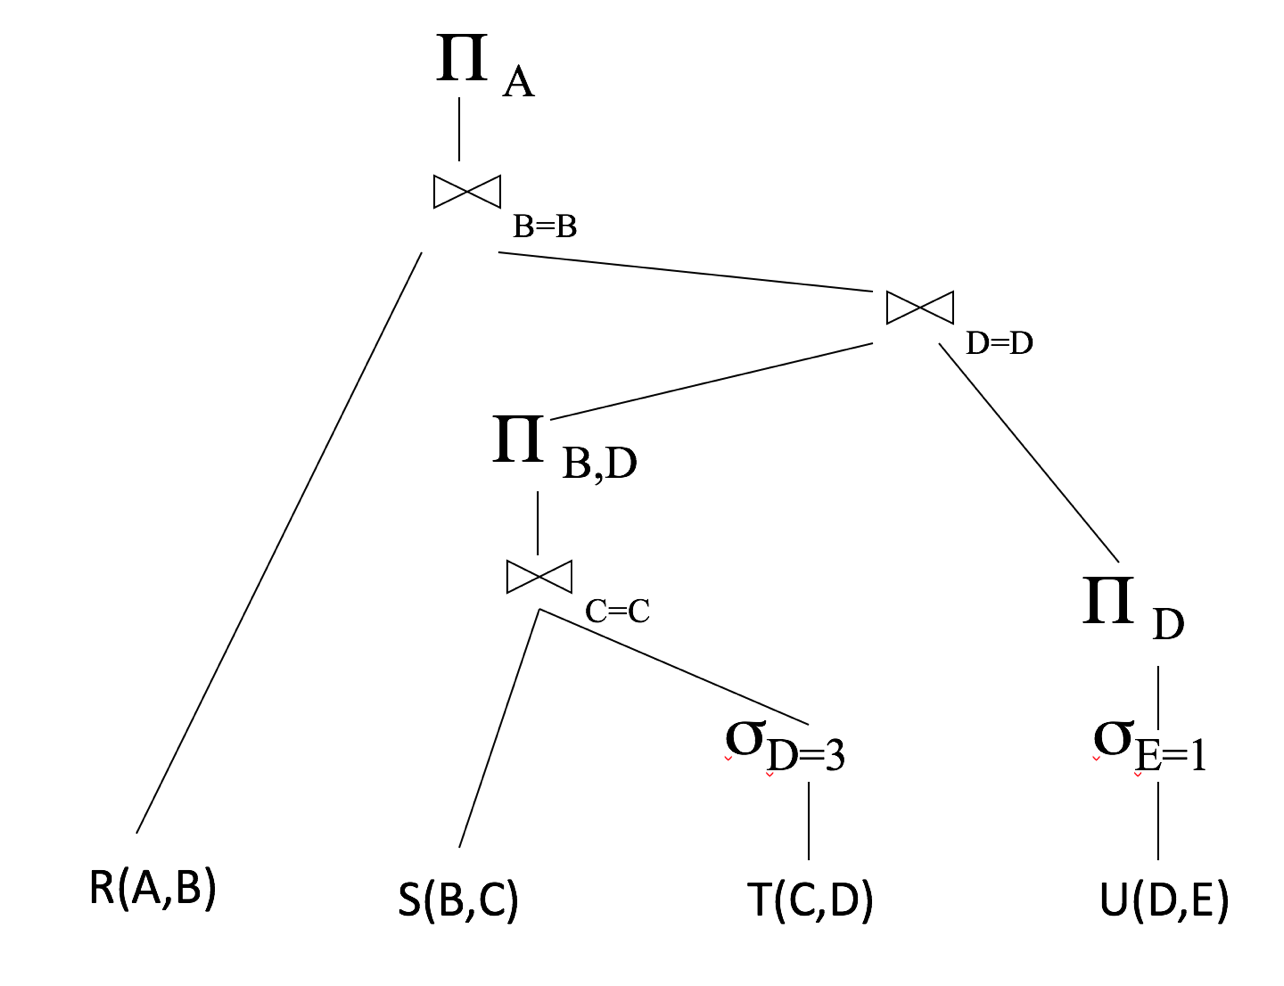

In [23]:
# ANSWER

u_filtered = Project(["D"], Select("E", 1, U))

t_filtered = Select("D", 3, T)

s_t_join = NJoin(S, t_filtered)

proj_bd = Project(["B", "D"], s_t_join)

s_t_u_join = NJoin(proj_bd, u_filtered)

final_join = NJoin(R, s_t_u_join)

# Final projection
task2c = Project(["A"], final_join)

render_markdown(task2c)
print(get_result(task2c))

[]


$\Pi_{A}$(( ( R(A,B) ) $\Join_{B}$ ( ( $\Pi_{B,D}$(( S(B,C) ) $\Join_{C}$ ( $\sigma_{D=3}$(T(C,D)) )) ) $\Join_{D}$ ( $\Pi_{D}$($\sigma_{E=1}$(U(D,E))) ) ) ) $\Join_{B,D}$ ( ( $\Pi_{B,D}$(( S(B,C) ) $\Join_{C}$ ( $\sigma_{D=3}$(T(C,D)) )) ) $\Join_{D}$ ( $\Pi_{D}$($\sigma_{E=1}$(U(D,E))) ) ))

In [24]:
# OPTIONAL ANSWER (SQL)
# below cell

In [25]:
%%sql
SELECT DISTINCT R.A
FROM R
JOIN (
    SELECT BD.B, BD.D
    FROM (
        SELECT S.B, T.D
        FROM S
        JOIN T ON S.C = T.C
        WHERE T.D = 3
    ) AS BD
    JOIN (
        SELECT D
        FROM U
        WHERE E = 1
    ) AS U_filtered ON BD.D = U_filtered.D
) AS FinalBD ON R.B = FinalBD.B;


 * sqlite://
Done.


A


Part 2: Optimization of Relational Algebra Expressions (100 pts.)
=============================

In [26]:
def cost_markdown(q):
    q.reset_count()
    get_result(q) # run the counters
    return display(HTML(markdown("Total Reads: {0}\n\n".format(q.total_count()) + q.toCount(0))))

In [27]:
%%sql
drop table if exists R; create table R(A int, B int);
drop table if exists S; create table S(B int, C int);
drop table if exists T; create table T(C int, D int);

 * sqlite://
Done.
Done.
Done.
Done.
Done.
Done.


[]

We start by generating some sample data for relations $R$ and $S$:

In [28]:
for b in range(0,5,1):
    for a in range(0,10,2):
        %sql INSERT INTO R VALUES (:a, :b);
for b in range(0,5,1):
    for c in range(0,10,2):
        %sql INSERT INTO S VALUES (:b, :c);
for c in range(0,5,1):
    for d in range(0,10,2):
        %sql INSERT INTO T VALUES (:c, :d);

 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite://
1 rows affected.
 * sqlite:

Then, let's look at the following RA expression:

In [29]:
r = %sql SELECT * FROM R;
R = BaseRelation(r, name="R")
s = %sql SELECT * FROM S;
S = BaseRelation(s, name="S")

x = Project(["B"], NJoin(R,S))
render_markdown(x)
print(get_result(x))

 * sqlite://
Done.
 * sqlite://
Done.


[(2,), (4,), (1,), (0,), (3,)]


$\Pi_{B}$(( R(A,B) ) $\Join_{B}$ ( S(B,C) ))



Let's look at what's going on under the hood using the `cost_markdown` function:

In [30]:
cost_markdown(x)

$\Pi_{['B']}$ [tuples read in: 125 out: 5]
$\Join_{B}$ [tuples read in: 650 out: 125]
R(A,B) has 25 tuples
S(B,C) has 25 tuples

Note that there are several simplifying assumptions in how we compute cost here.  For one, note that we don't assume anything about being able to cache intermediate results in any way (either in buffer or on disk).  For another one, note how is the join done... what algorithm are we using here?

Note that we can also just get the total count of reads:

In [31]:
x.total_count()

775

### Task 1: Optimizing the IO Cost (20 pts.)

Can you find a logically equivalent form that uses fewer total reads?

In [32]:
r_proj = Project(["B"], R)
s_proj = Project(["B"], S)
x_r = NJoin(r_proj, s_proj)

render_markdown(x_r)

print(get_result(x_r))
cost_markdown(x_r)

[(2,), (4,), (1,), (0,), (3,)]


( $\Pi_{B}$(R(A,B)) ) $\Join_{B}$ ( $\Pi_{B}$(S(B,C)) )

$\Join_{B}$ [tuples read in: 30 out: 5]
$\Pi_{['B']}$ [tuples read in: 25 out: 5]
R(A,B) has 25 tuples
$\Pi_{['B']}$ [tuples read in: 125 out: 25]
S(B,C) has 25 tuples

### Task 2: Comparing costs (40 pts.)

Let's explore how the cost of the two expressions compare as the data size increases, and with different numbers of distinct values in the data.  Given that $R$ has $N$ values, $S$ has $M$ values, you can assume that $N=M$ to simplify, and that they will both have _the same number of unique $B$ values_.

You can do this any way you choose, but we outline one way below:

We'll start with a function for each cost that will take as input:
* The number of tuples in $R$, $N$
* The number of distinct $B$ values in $R$, $N_B$
* The number of tuples in $R\Join_B S$, $O_1$
* The number of tuples in $\Pi_B(R\Join_B S)$, $O_2$

`def cost_1` calculates reads for -> $\Pi_{B}$(( R(A,B) ) $\Join_{B}$ ( S(B,C) )) or `Project(["B"], NJoin(R,S))`

`def cost_2` calculates reads for -> Your answer for the Task 1

Your function should return the total number of reads as in the `cost_markdown` function

In [33]:
def cost_1(N, M, N_B, M_B, O_1, O_2):
    # Join first, then project
    cost = N + M + O_1 + O_2
    return cost

def cost_2(N, M, N_B, M_B, O_1, O_2):
    # Project first, then join (optimized)
    cost = N + M + N_B + M_B + O_2
    return cost

print(cost_1(25, 25, 5, 5, 125, 5))
print(cost_2(25, 25, 5, 5, 125, 5))

180
65


We can plot this as a function of $N$ (assume $N=M$ for simplicity), given 5 distinct $B$ values and a rough estimate of the intermediate output counts:

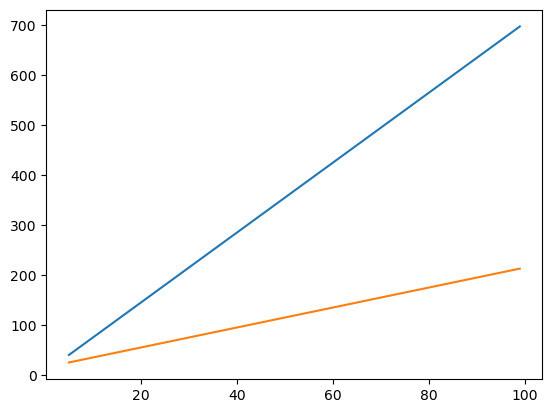

In [34]:
%matplotlib inline

import matplotlib
import numpy as np
import matplotlib.pyplot as plt

B = 5
nrange = range(5,100)

# Plot
plt.plot(nrange, [cost_1(n, n, B, B, n*B, B) for n in nrange])
plt.plot(nrange, [cost_2(n, n, B, B, n*B, B) for n in nrange])
plt.show()

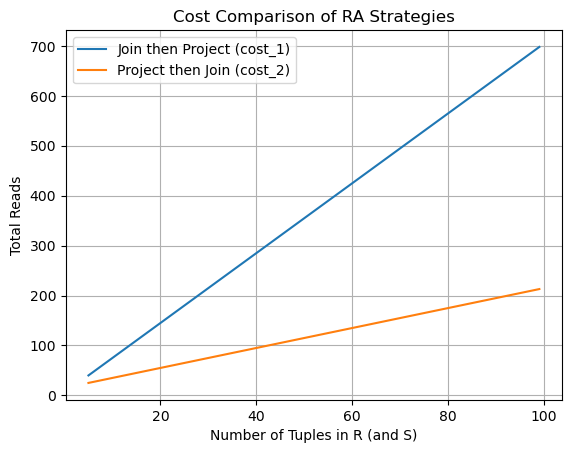

In [35]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

B = 5
nrange = range(5, 100)

plt.plot(nrange, [cost_1(n, n, B, B, n*B, B) for n in nrange], label="Join then Project (cost_1)")
plt.plot(nrange, [cost_2(n, n, B, B, n*B, B) for n in nrange], label="Project then Join (cost_2)")
plt.xlabel("Number of Tuples in R (and S)")
plt.ylabel("Total Reads")
plt.title("Cost Comparison of RA Strategies")
plt.legend()
plt.grid(True)
plt.show()


### Task 3: Optimizing some other expressions (40 pts.)

Can you optimize the below expressions, using the tools above?

#### Task 3a (20 pts.)

In [36]:
x = Select("A", 2, Project(["A","C"], NJoin(R,S)))
render_markdown(x)
print(get_result(x))
cost_markdown(x)

[(2, 2), (2, 8), (2, 4), (2, 0), (2, 6)]


$\sigma_{A=2}$($\Pi_{A,C}$(( R(A,B) ) $\Join_{B}$ ( S(B,C) )))

Total Reads: 800

$\sigma_{A=2}$ [tuples read in: 25 out: 5]
$\Pi_{['A', 'C']}$ [tuples read in: 125 out: 25]
$\Join_{B}$ [tuples read in: 650 out: 125]
R(A,B) has 25 tuples
S(B,C) has 25 tuples

In [37]:
r_filtered = Select("A", 2, R)
join_rs = NJoin(r_filtered, S)
x_r = Project(["A", "C"], join_rs)

render_markdown(x_r)

print(get_result(x_r))
cost_markdown(x_r)

[(2, 4), (2, 0), (2, 6), (2, 2), (2, 8)]


$\Pi_{A,C}$(( $\sigma_{A=2}$(R(A,B)) ) $\Join_{B}$ ( S(B,C) ))

Total Reads: 180

$\Pi_{['A', 'C']}$ [tuples read in: 25 out: 5]
$\Join_{B}$ [tuples read in: 130 out: 25]
$\sigma_{A=2}$ [tuples read in: 25 out: 5]
R(A,B) has 25 tuples
S(B,C) has 25 tuples

#### Task 3b (20 pts.)

In [38]:
t = %sql SELECT * FROM T;
T = BaseRelation(t, name="T")

x = Select("C", 0, Project(["A","C"], Select("B", 0, NJoin(NJoin(R, S), T))))
render_markdown(x)
print(get_result(x))
cost_markdown(x)

 * sqlite://
Done.


[(4, 0), (6, 0), (0, 0), (2, 0), (8, 0)]


$\sigma_{C=0}$($\Pi_{A,C}$($\sigma_{B=0}$(( ( R(A,B) ) $\Join_{B}$ ( S(B,C) ) ) $\Join_{C}$ ( T(C,D) ))))

Total Reads: 4365

$\sigma_{C=0}$ [tuples read in: 15 out: 5]
$\Pi_{['A', 'C']}$ [tuples read in: 75 out: 15]
$\sigma_{B=0}$ [tuples read in: 375 out: 75]
$\Join_{C}$ [tuples read in: 3250 out: 375]
$\Join_{B}$ [tuples read in: 650 out: 125]
R(A,B) has 25 tuples
S(B,C) has 25 tuples
T(C,D) has 25 tuples

In [39]:
r_filtered = Select("B", 0, R)
rs_join = NJoin(r_filtered, S)
rst_join = NJoin(rs_join, T)
c_filtered = Select("C", 0, rst_join)
x_r = Project(["A", "C"], c_filtered)


render_markdown(x_r)

print(get_result(x_r))
cost_markdown(x_r)

[(4, 0), (0, 0), (2, 0), (8, 0), (6, 0)]


$\Pi_{A,C}$($\sigma_{C=0}$(( ( $\sigma_{B=0}$(R(A,B)) ) $\Join_{B}$ ( S(B,C) ) ) $\Join_{C}$ ( T(C,D) )))

Total Reads: 905

$\Pi_{['A', 'C']}$ [tuples read in: 25 out: 5]
$\sigma_{C=0}$ [tuples read in: 75 out: 25]
$\Join_{C}$ [tuples read in: 650 out: 75]
$\Join_{B}$ [tuples read in: 130 out: 25]
$\sigma_{B=0}$ [tuples read in: 25 out: 5]
R(A,B) has 25 tuples
S(B,C) has 25 tuples
T(C,D) has 25 tuples

### Task 4: Optimizing indexes

In [40]:
%sql sqlite:///complaint.db
import time
%sql drop index if exists helpful_index;
%sql analyze

   sqlite://
 * sqlite:///complaint.db
Done.
   sqlite://
 * sqlite:///complaint.db
Done.


[]

In [41]:
%%sql
PRAGMA index_list('complaints');

   sqlite://
 * sqlite:///complaint.db
Done.


seq,name,unique,origin,partial
0,zip_index,0,c,0
1,state_product_index,0,c,0
2,state_index,0,c,0


Let's play with the [consumer complaint database](https://catalog.data.gov/dataset/consumer-complaint-database) from data.gov

In [42]:
%sql select count(*) from complaints;

   sqlite://
 * sqlite:///complaint.db
Done.


count(*)
79468


In [43]:
%sql select * from complaints limit 5;

   sqlite://
 * sqlite:///complaint.db
Done.


Date_received,Product,Subproduct,Issue,Subissue,Consumer_narrative,Company_public_response,Company,State,ZIP_code,Submitted_via,Date_sent_to_company,Company_response,Timely_response,Consumer_disputed,Complaint_ID
12/30/2015,Mortgage,Other mortgage,"Loan servicing, payments, escrow account",,,Company chooses not to provide a public response,U.S. Bancorp,TN,38138,,N/A,Referral,01/05/2016,Closed with explanation,Yes
12/12/2015,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",,,Company chooses not to provide a public response,Citibank,NY,13021,,N/A,Referral,12/23/2015,Closed with explanation,Yes
12/02/2015,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",,,,Nationstar Mortgage,MI,49102,,N/A,Referral,12/17/2015,Closed with explanation,Yes
12/02/2015,Bank account or service,Other bank product/service,"Account opening, closing, or management",,,Company chooses not to provide a public response,Wells Fargo & Company,,,,N/A,Referral,12/07/2015,Closed with explanation,Yes
12/22/2015,Mortgage,Conventional fixed mortgage,"Loan servicing, payments, escrow account",,,,Nationstar Mortgage,FL,33484,Older American,Consent not provided,Web,01/06/2016,Closed with explanation,Yes


The syntax to create a view is below
> create index (index_name) on (table)(attributes)

In [44]:
%%sql drop index if exists zip_index;
create index zip_index on complaints(zip_code);
analyze

   sqlite://
 * sqlite:///complaint.db
Done.
Done.
Done.


[]

In [45]:
%%sql
select zip_code, count(*) as c
from complaints group by zip_code
order by c desc limit 5;

   sqlite://
 * sqlite:///complaint.db
Done.


ZIP_code,c
None,21619
Closed with explanation,4267
,760
Closed with non-monetary relief,646
Yes,607


In [46]:
%%sql select product, count(*)
from complaints c1 where ZIP_CODE = '48382'
group by product;

   sqlite://
 * sqlite:///complaint.db
Done.


Product,count(*)
Mortgage,126
Student loan,1


Let's get down to business... Indexing complainers!

For pedagogical purposes, we'll use _likelihood_ function:
  * likelihood(X,Y) does not change X's value
  * instead it tells the DBMS the fraction of calls on which we believe X holds.
      * 0.0 is lowest, 1.0 is highest.
  * It's a form of _hint_ for the optimizer

In [47]:
%%sql
explain query plan
select product, count(*) from complaints c1
where likelihood(ZIP_CODE = '48383' or ZIP_CODE='44444', 1.0)
group by product;

   sqlite://
 * sqlite:///complaint.db
Done.


id,parent,notused,detail
8,0,0,MULTI-INDEX OR
9,8,0,INDEX 1
15,9,0,SEARCH c1 USING INDEX zip_index (ZIP_code=?)
20,8,0,INDEX 2
26,20,0,SEARCH c1 USING INDEX zip_index (ZIP_code=?)
32,0,0,USE TEMP B-TREE FOR GROUP BY


In [48]:
%%sql
explain query plan
select product, count(*) from complaints c1
where likelihood(ZIP_CODE = '48383' or ZIP_CODE='44444', 0.0)
group by product;

   sqlite://
 * sqlite:///complaint.db
Done.


id,parent,notused,detail
7,0,0,SEARCH c1 USING INDEX zip_index (ZIP_code=?)
25,0,0,USE TEMP B-TREE FOR GROUP BY


So... does it make a difference in execution time?

... Well, some it's a small database in memory...

In [49]:
start_scan = time.time()
%sql select product, count(*) from complaints c1 where likelihood(ZIP_CODE = '48382' or ZIP_CODE='44444', 1.0) group by product;
scan_time = time.time() - start_scan

start_index = time.time()
%sql select product, count(*) from complaints c1 where likelihood(ZIP_CODE = '48382' or ZIP_CODE='44444', 0.0) group by product;
index_time  = time.time() - start_index
print("time for scan={0} time for index={1}".format(scan_time, index_time))
print("\t So about {0} times faster".format(scan_time/index_time))

   sqlite://
 * sqlite:///complaint.db
Done.
   sqlite://
 * sqlite:///complaint.db
Done.
time for scan=0.001714944839477539 time for index=0.0016689300537109375
	 So about 1.0275714285714286 times faster


<center>Covering Indexes</center>

We say that an index is _covering_ if all the needed columns are in the index.
 * Needed columns is the union of those in WHERE _and_ SELECT.
 * Means that the query can be answere using the index--without reading the table!

In [50]:
%%sql drop index if exists helpful_index;
create index helpful_index on
complaints(zip_code, product, complaint_id);

   sqlite://
 * sqlite:///complaint.db
Done.
Done.


[]

Which plan happens for this query?
> select product, count(*)<br>
> from complaints <br>
> where likelihood(ZIP_CODE = '48382', 1.0)
> <br>group by product;

NB: Using zip_index, this would be a scan!

In [51]:
%%sql
explain query plan select product, count(*)
from complaints c1
where likelihood(ZIP_CODE = '48382' or ZIP_CODE='44444', 1.0) group by product;

   sqlite://
 * sqlite:///complaint.db
Done.


id,parent,notused,detail
8,0,0,MULTI-INDEX OR
9,8,0,INDEX 1
15,9,0,SEARCH c1 USING COVERING INDEX helpful_index (ZIP_code=?)
20,8,0,INDEX 2
26,20,0,SEARCH c1 USING COVERING INDEX helpful_index (ZIP_code=?)
32,0,0,USE TEMP B-TREE FOR GROUP BY


* The index is _smaller_ in absolute data size.
* The DBMS knows this, and it picks the right index!

Save and submit your notebook file (.ipynb) to the form below with your name and student ID. Do not include the database file or any other file. Only one notebook file is sufficient.

https://forms.gle/13tLPuCLzuqZtG7b7

**Note:** *You **can** submit your exercise notebook remotely.*